In [37]:
# NorthStar Urban Mobility and Logistics
## Databases and Analytics Assignment
###Jesna Jasir-32146928

In [38]:
!pip install pymongo dnspython pandas numpy matplotlib seaborn


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [40]:
#Github details
GITHUB_USER = "JJ21git"
REPO        = "Northstar-Analytics"
BRANCH      = "main"

In [41]:
BASE_URL = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO}/{BRANCH}/"

In [42]:
# Load all 9 CSV files directly from GitHub
orders      = pd.read_csv(BASE_URL + "orders.csv")
deliveries  = pd.read_csv(BASE_URL + "deliveries.csv")
customers   = pd.read_csv(BASE_URL + "customers.csv")
complaints  = pd.read_csv(BASE_URL + "complaints.csv")
drivers     = pd.read_csv(BASE_URL + "drivers.csv")
vehicles    = pd.read_csv(BASE_URL + "vehicles.csv")
incidents   = pd.read_csv(BASE_URL + "incidents.csv")
app_events  = pd.read_csv(BASE_URL + "app_events.csv")
hubs        = pd.read_csv(BASE_URL + "hubs.csv")

print("All files loaded from GitHub successfully!")
print(f"   Orders:      {len(orders):,} records")
print(f"   Deliveries:  {len(deliveries):,} records")
print(f"   Customers:   {len(customers):,} records")
print(f"   Complaints:  {len(complaints):,} records")
print(f"   Drivers:     {len(drivers):,} records")
print(f"   Vehicles:    {len(vehicles):,} records")
print(f"   Incidents:   {len(incidents):,} records")
print(f"   App Events:  {len(app_events):,} records")
print(f"   Hubs:        {len(hubs):,} records")


All files loaded from GitHub successfully!
   Orders:      1,250 records
   Deliveries:  950 records
   Customers:   650 records
   Complaints:  320 records
   Drivers:     170 records
   Vehicles:    120 records
   Incidents:   280 records
   App Events:  640 records
   Hubs:        8 records


In [43]:
#Set a clean plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('All libraries imported successfully!')

All libraries imported successfully!


In [44]:
#Standardising all zone or category text to Title Case
def standardise_zones(df, columns):
    """Convert all zone/category strings to consistent Title Case."""
    for col in columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.title()
    return df

orders     = standardise_zones(orders,     ['pickup_zone', 'dropoff_zone', 'priority_level', 'service_type'])
customers  = standardise_zones(customers,  ['home_zone', 'customer_type'])
drivers    = standardise_zones(drivers,    ['base_zone', 'employment_type'])
vehicles   = standardise_zones(vehicles,   ['assigned_zone', 'maintenance_status'])
deliveries = standardise_zones(deliveries, ['delivery_status'])
complaints = standardise_zones(complaints, ['complaint_type', 'severity', 'status'])

#Parse date columns
orders['order_created_at']          = pd.to_datetime(orders['order_created_at'],          errors='coerce')
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'],         errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
complaints['created_at']            = pd.to_datetime(complaints['created_at'],            errors='coerce')

#Check for missing values
print('=== Missing Values Summary ===')
for name, df in [('orders', orders), ('deliveries', deliveries), ('complaints', complaints)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f'\n{name}:')
        print(missing.to_string())

#Fill missing numeric columns with median
for col in ['customer_rating_post_delivery', 'fuel_or_charge_cost']:
    deliveries[col] = deliveries[col].fillna(deliveries[col].median())

print('\nData cleaning complete.')


=== Missing Values Summary ===

orders:
booking_channel    25

deliveries:
delivery_completed_at            19
customer_rating_post_delivery    14

complaints:
compensation_amount    16

Data cleaning complete.


In [45]:
#Preview the orders dataset
print('Orders dataset preview:')
orders.head()


Orders dataset preview:


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,0


In [46]:
#Core order value statistics using NumPy
order_values = np.array(orders['order_value'].dropna())
route_dist   = np.array(deliveries['route_distance_km'].dropna())
ratings      = np.array(deliveries['customer_rating_post_delivery'].dropna())

print('='*50)
print('ORDER VALUE STATISTICS')
print('='*50)
print(f'  Mean:       £{np.mean(order_values):.2f}')
print(f'  Median:     £{np.median(order_values):.2f}')
print(f'  Std Dev:    £{np.std(order_values):.2f}')
print(f'  Min:        £{np.min(order_values):.2f}')
print(f'  Max:        £{np.max(order_values):.2f}')
print(f'  25th pctile:£{np.percentile(order_values, 25):.2f}')
print(f'  75th pctile:£{np.percentile(order_values, 75):.2f}')

print('\n' + '='*50)
print('ROUTE DISTANCE STATISTICS')
print('='*50)
print(f'  Mean:    {np.mean(route_dist):.2f} km')
print(f'  Median:  {np.median(route_dist):.2f} km')
print(f'  Std Dev: {np.std(route_dist):.2f} km')

print('\n' + '='*50)
print('CUSTOMER RATING STATISTICS')
print('='*50)
print(f'  Mean:    {np.mean(ratings):.2f} / 5.0')
print(f'  Median:  {np.median(ratings):.2f} / 5.0')
print(f'  Std Dev: {np.std(ratings):.2f}')

#Correlation: route distance vs fuel cost
dist_cost_corr = np.corrcoef(
    deliveries['route_distance_km'].dropna(),
    deliveries['fuel_or_charge_cost'].dropna()
)[0, 1]
print(f'\nCorrelation (distance vs fuel cost): {dist_cost_corr:.4f}')
print('Interpretation:', 'Strong positive' if dist_cost_corr > 0.7 else 'Moderate' if dist_cost_corr > 0.4 else 'Weak', 'relationship')


ORDER VALUE STATISTICS
  Mean:       £91.05
  Median:     £76.53
  Std Dev:    £60.89
  Min:        £2.04
  Max:        £510.06
  25th pctile:£47.91
  75th pctile:£121.10

ROUTE DISTANCE STATISTICS
  Mean:    13.91 km
  Median:  12.84 km
  Std Dev: 7.47 km

CUSTOMER RATING STATISTICS
  Mean:    3.87 / 5.0
  Median:  4.04 / 5.0
  Std Dev: 0.89

Correlation (distance vs fuel cost): 0.5242
Interpretation: Moderate relationship


In [47]:
# Merge deliveries with orders to get full context
df = deliveries.merge(orders, on='order_id', how='left')

#Delivery outcome rates overall
status_counts = deliveries['delivery_status'].value_counts()
status_pct    = (status_counts / len(deliveries) * 100).round(1)

print('=== Delivery Outcome Summary ===')
for status, count in status_counts.items():
    print(f'  {status:10s}: {count:4d} ({status_pct[status]:.1f}%)')

#Failure rate by service type
print('\n=== Failure Rate by Service Type ===')
svc_perf = df.groupby('service_type')['delivery_status'].value_counts(normalize=True).unstack(fill_value=0)
if 'Failed' in svc_perf.columns:
    svc_perf['failure_pct'] = (svc_perf['Failed'] * 100).round(1)
    print(svc_perf[['failure_pct']].sort_values('failure_pct', ascending=False).to_string())

#Manual route override analysis
print('\n=== Manual Route Override Analysis ===')
override_by_status = df.groupby('delivery_status')['manual_route_override_count'].mean().round(2)
print('Average route overrides per delivery status:')
print(override_by_status.to_string())
print('\nInsight: Higher manual overrides suggest poor route planning or driver behaviour issues.')


=== Delivery Outcome Summary ===
  Ontime    :  616 (64.8%)
  Delayed   :  202 (21.3%)
  Failed    :  132 (13.9%)

=== Failure Rate by Service Type ===
delivery_status  failure_pct
service_type                
Business                19.8
Medical                 14.8
Passenger               14.5
Retail                  12.5
Parcel                  10.9

=== Manual Route Override Analysis ===
Average route overrides per delivery status:
delivery_status
Delayed    1.07
Failed     1.04
Ontime     0.92

Insight: Higher manual overrides suggest poor route planning or driver behaviour issues.


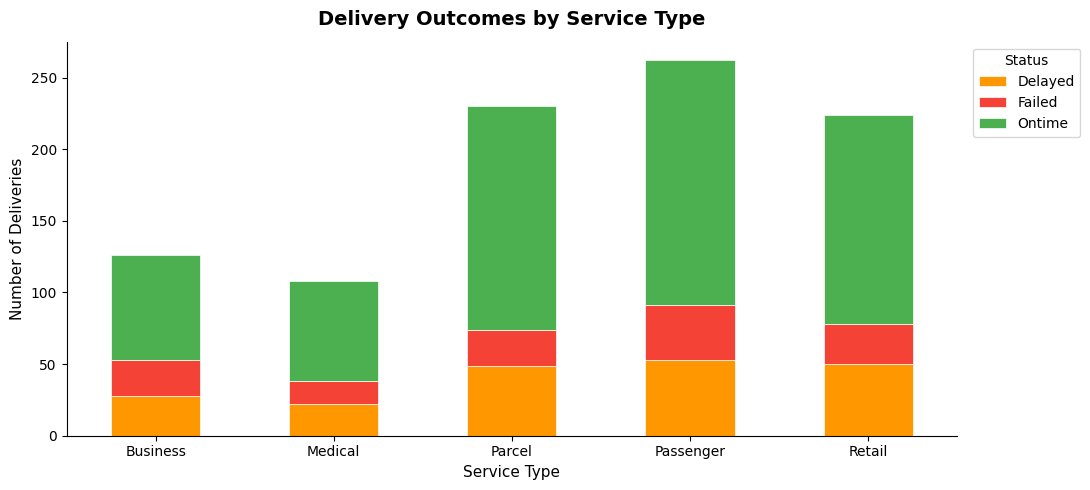

Chart saved as chart1_delivery_status_by_service.png


In [48]:
#delivery status by service type
status_svc = df.groupby(['service_type', 'delivery_status']).size().unstack(fill_value=0)

colors = {'Ontime': '#4CAF50', 'Delayed': '#FF9800', 'Failed': '#F44336'}
#Handle case variations
col_colors = [colors.get(c, '#999999') for c in status_svc.columns]

ax = status_svc.plot(kind='bar', stacked=True, color=col_colors, figsize=(11, 5), edgecolor='white', linewidth=0.5)
plt.title('Delivery Outcomes by Service Type', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Service Type', fontsize=11)
plt.ylabel('Number of Deliveries', fontsize=11)
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart1_delivery_status_by_service.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as chart1_delivery_status_by_service.png')


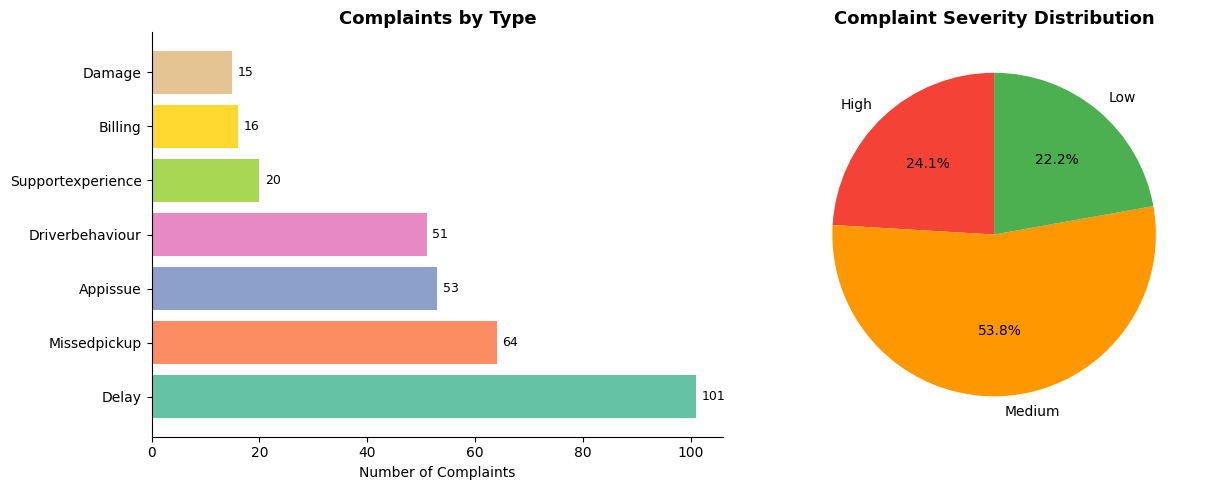

Chart saved.

=== Average Compensation by Severity ===
severity
High      38.85
Low        9.06
Medium    17.37


In [49]:
#Complaints by type and severity
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Complaint types
comp_type = complaints['complaint_type'].value_counts()
axes[0].barh(comp_type.index, comp_type.values, color=sns.color_palette('Set2', len(comp_type)))
axes[0].set_title('Complaints by Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Complaints')
for i, v in enumerate(comp_type.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

# Plot 2: Severity distribution
sev_order = ['High', 'Medium', 'Low']
sev_counts = complaints['severity'].value_counts().reindex(sev_order, fill_value=0)
axes[1].pie(sev_counts, labels=sev_counts.index, autopct='%1.1f%%',
            colors=['#F44336', '#FF9800', '#4CAF50'], startangle=90)
axes[1].set_title('Complaint Severity Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_complaints.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

# Average compensation by severity
print('\n=== Average Compensation by Severity ===')
avg_comp = complaints.groupby('severity')['compensation_amount'].mean().round(2)
print(avg_comp.to_string())

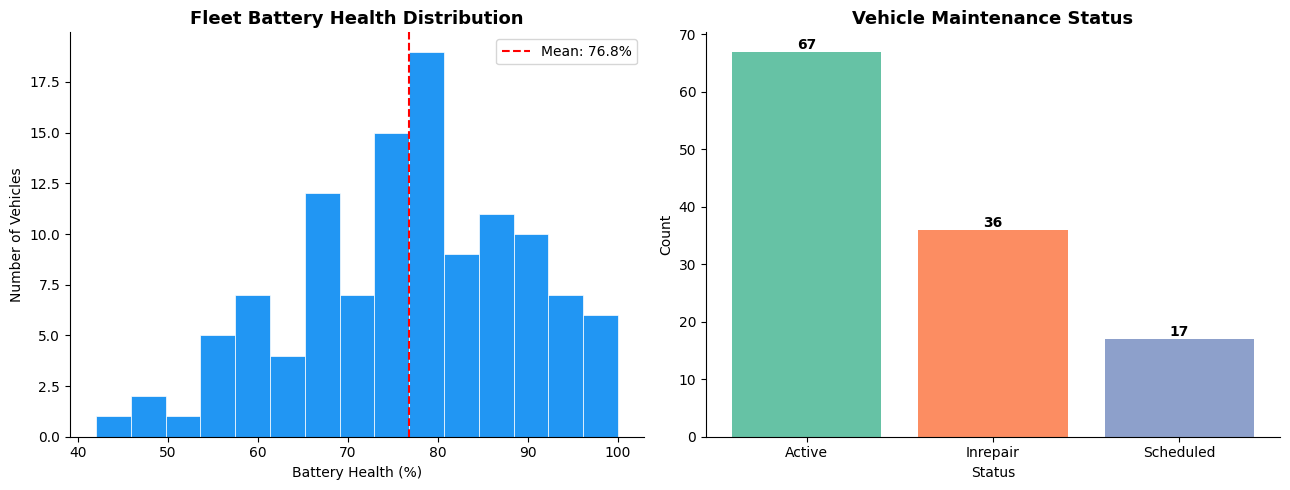


Vehicles with battery health below 50%: 3
As percentage of fleet: 2.5%


In [50]:
#Vehicle battery health and maintenance status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Battery health histogram
axes[0].hist(vehicles['battery_health_pct'].dropna(), bins=15, color='#2196F3', edgecolor='white', linewidth=0.5)
axes[0].axvline(vehicles['battery_health_pct'].mean(), color='red', linestyle='--', label=f"Mean: {vehicles['battery_health_pct'].mean():.1f}%")
axes[0].set_title('Fleet Battery Health Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Battery Health (%)')
axes[0].set_ylabel('Number of Vehicles')
axes[0].legend()

# Plot 2: Maintenance status
maint = vehicles['maintenance_status'].value_counts()
axes[1].bar(maint.index, maint.values, color=sns.color_palette('Set2', len(maint)))
axes[1].set_title('Vehicle Maintenance Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Count')
for i, v in enumerate(maint.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_vehicles.png', dpi=150, bbox_inches='tight')
plt.show()

# Vehicles needing attention (battery < 50%)
low_battery = vehicles[vehicles['battery_health_pct'] < 50]
print(f'\nVehicles with battery health below 50%: {len(low_battery)}')
print(f'As percentage of fleet: {len(low_battery)/len(vehicles)*100:.1f}%')


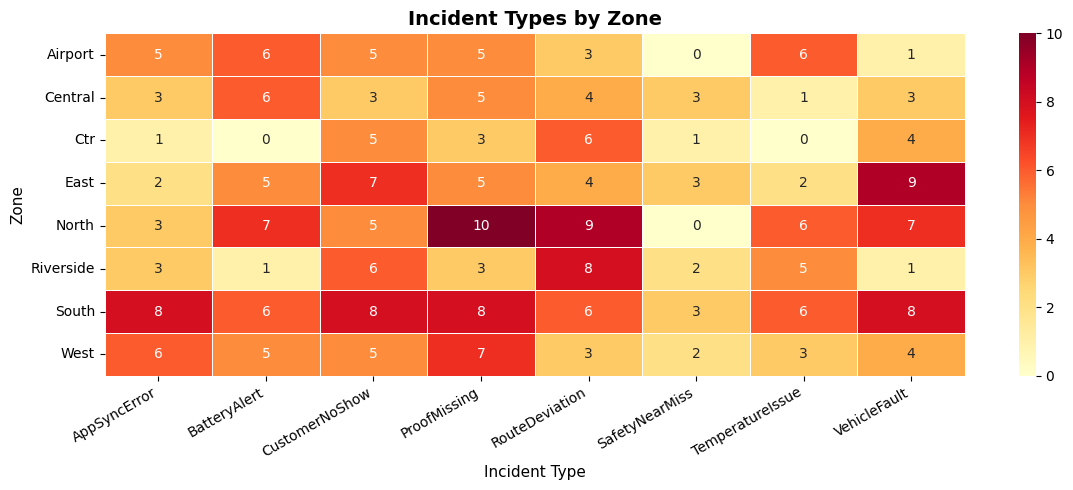

Incident heatmap saved.


In [51]:
#Join incidents -> deliveries -> orders to get zone info
inc_del = incidents.merge(deliveries[['delivery_id', 'order_id', 'driver_id', 'vehicle_id']], on='delivery_id', how='left')
inc_full = inc_del.merge(orders[['order_id', 'pickup_zone', 'service_type']], on='order_id', how='left')

# Incident type vs pickup zone pivot
heatmap_data = inc_full.groupby(['pickup_zone', 'incident_type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, linecolor='white')
plt.title('Incident Types by Zone', fontsize=14, fontweight='bold')
plt.xlabel('Incident Type', fontsize=11)
plt.ylabel('Zone', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart4_incident_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Incident heatmap saved.')

In [ ]:
#Driver performance: rating vs on-time delivery rate
driver_del = deliveries.groupby('driver_id').agg(
    total_deliveries = ('delivery_id', 'count'),
    ontime_rate      = ('delivery_status', lambda x: (x == 'Ontime').mean()),
    avg_rating       = ('customer_rating_post_delivery', 'mean'),
    avg_overrides    = ('manual_route_override_count', 'mean')
).reset_index()

driver_perf = driver_del.merge(drivers[['driver_id', 'driver_rating', 'years_experience', 'training_score']], on='driver_id', how='left')

plt.figure(figsize=(10, 5))
scatter = plt.scatter(
    driver_perf['driver_rating'],
    driver_perf['ontime_rate'],
    c=driver_perf['training_score'], cmap='RdYlGn', s=60, alpha=0.7, edgecolors='white', linewidth=0.5
)
plt.colorbar(scatter, label='Training Score')

# Trend line
valid = driver_perf[['driver_rating', 'ontime_rate']].dropna()
z = np.polyfit(valid['driver_rating'], valid['ontime_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['driver_rating'].min(), valid['driver_rating'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')

plt.title('Driver Rating vs On-Time Delivery Rate\n(Colour = Training Score)', fontsize=13, fontweight='bold')
plt.xlabel('Driver Rating (1–5)', fontsize=11)
plt.ylabel('On-Time Delivery Rate', fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig('chart5_driver_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation
corr = np.corrcoef(valid['driver_rating'], valid['ontime_rate'])[0,1]
print(f'Correlation between driver rating and on-time rate: {corr:.4f}')


In [ ]:
#Monthly order volume and revenue trend
orders['month'] = orders['order_created_at'].dt.to_period('M')
monthly = orders.groupby('month').agg(
    order_count = ('order_id', 'count'),
    total_revenue = ('order_value', 'sum')
).reset_index()
monthly['month_str'] = monthly['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['month_str'], monthly['order_count'], color='#2196F3', alpha=0.7, label='Order Count')
ax2.plot(monthly['month_str'], monthly['total_revenue'], color='#FF5722', marker='o', linewidth=2, label='Revenue')

ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Order Count', fontsize=11, color='#2196F3')
ax2.set_ylabel('Total Revenue (£)', fontsize=11, color='#FF5722')
plt.title('Monthly Order Volume and Revenue', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('chart6_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Monthly trend chart saved.')


In [ ]:
#Compute and display key findings
total_orders = len(orders)
failed_del   = (deliveries['delivery_status'] == 'Failed').sum()
delayed_del  = (deliveries['delivery_status'] == 'Delayed').sum()
open_comp    = (complaints['status'] == 'Open').sum()
high_sev_comp = (complaints['severity'] == 'High').sum()
vehicles_inrepair = (vehicles['maintenance_status'] == 'Inrepair').sum()
avg_comp_val = complaints['compensation_amount'].mean()

print('='*50)
print(' NORTHSTAR KEY ANALYTICS FINDINGS ')
print('='*50)
print(f'  Total Orders:              {total_orders:,}')
print(f'  Failed Deliveries:         {failed_del:,} ({failed_del/len(deliveries)*100:.1f}%)')
print(f'  Delayed Deliveries:        {delayed_del:,} ({delayed_del/len(deliveries)*100:.1f}%)')
print(f'  Open Complaints:           {open_comp:,}')
print(f'  High-Severity Complaints:  {high_sev_comp:,}')
print(f'  Avg Compensation Paid:     £{avg_comp_val:.2f}')
print(f'  Vehicles In-Repair:        {vehicles_inrepair}')
print(f'  Total Est. Compensation:   £{complaints["compensation_amount"].sum():,.2f}')
print('='*50)
print('\nConclusion: NorthStar has significant service reliability issues.')
print('Failure and delay combined affect over 35% of all deliveries.')
print('High open complaint volumes indicate poor resolution processes.')
